In [1]:
import argparse
import json
import logging
import os
import pickle
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    brier_score_loss,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder as SkOHE, StandardScaler
from lifelines import CoxPHFitter, KaplanMeierFitter
import xgboost as xgb
import lightgbm as lgb

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)
sns.set_theme(style="whitegrid", font_scale=1.1)



In [2]:
def create_spark(app="FannieMae_V3", driver_mem="24g"):
    from pyspark.sql import SparkSession
    return (
        SparkSession.builder.appName(app)
        .config("spark.driver.memory",                          driver_mem)
        .config("spark.serializer",
                "org.apache.spark.serializer.KryoSerializer")
        .config("spark.kryoserializer.buffer.max",              "512m")
        .config("spark.sql.adaptive.enabled",                   "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled","true")
        .config("spark.sql.adaptive.skewJoin.enabled",          "true")
        .config("spark.sql.shuffle.partitions",                 "400")
        .config("spark.sql.autoBroadcastJoinThreshold",         "100m")
        .config("spark.sql.parquet.filterPushdown",             "true")
        .config("spark.memory.offHeap.enabled",                 "true")
        .config("spark.memory.offHeap.size",                    "8g")
        .getOrCreate()
    )

In [9]:
#spark = create_spark()

In [3]:
NUMERIC_FEATURES = [
    "fico", "orig_interest_rate", "current_interest_rate",
    "refi_incentive", "refi_incentive_pos",
    "rate_spread_to_10y", "spread_pos",
    "orig_ltv", "dti", "orig_upb", "upb_fraction", "equity_proxy",
    "loan_age", "age_sq", "burnout", "pct_term_elapsed",
    "orig_loan_term", "remaining_months_to_mat", "rate_duration",
    "burnout_x_refi", "fico_x_refi", "ltv_x_refi",
    "ph_delinq_count", "excess_principal", "gs10_monthly", "logit_rate_spread_to_10y"
]

CATEGORICAL_FEATURES = [
    "channel", "loan_purpose", "property_type", "occupancy_status",
    "fico_bucket", "seasoning_bucket", "month_of_year", "vintage_year",
]

BINARY_FEATURES = [
    "high_ltv", "term_15y", "is_refi", "is_cashout", "is_io",
    "has_ppm", "modified", "is_investor", "is_high_bal",
    "first_time_buyer", "in_forbearance", "has_deferral",
    "is_judicial_state", "is_hltv_refi",
]
TARGET_COL     = "smm_target"

In [4]:
import pyarrow.dataset as ds

def read_first_n_rows(path, n=100_000):
    dataset = ds.dataset(path, format="parquet")

    batches = []
    total = 0

    for batch in dataset.to_batches(batch_size=min(n, 1_000_000)):
        pdf = batch.to_pandas()
        batches.append(pdf)

        total += len(pdf)
        if total >= n:
            break

    return pd.concat(batches, ignore_index=True).head(n)


def load_raw_data(out_path: str, sample_frac: float = 0.1):
    export_dir = os.path.join(out_path, "exported")

    with open(os.path.join(export_dir, "columns.json")) as fh:
        col_meta = json.load(fh)

    log.info("Loading raw train Parquet …")
    #train_pd = pd.read_parquet(os.path.join(export_dir, "train_raw.parquet"))
    train_pd = read_first_n_rows(os.path.join(export_dir, "train_raw.parquet"), 1_000)
    log.info("Loading raw test Parquet …")
    #test_pd = pd.read_parquet(os.path.join(export_dir, "test_raw.parquet"))
    test_pd = read_first_n_rows(os.path.join(export_dir, "test_raw.parquet"), 5_000_000)

    log.info("Full sizes: train={:,}, test={:,}".format(len(train_pd), len(test_pd)))

    if sample_frac < 1.0:
        train_pd = train_pd.sample(frac=sample_frac, random_state=SEED)
        test_pd  = test_pd.sample(frac=sample_frac, random_state=SEED)
        log.info("After sampling (%.0f%%): train={:,}, test={:,}".format(
            len(train_pd), len(test_pd)) % (sample_frac * 100))

    return train_pd, test_pd, col_meta

In [5]:
out_path = "D:/HSE/Diplom/models"

In [6]:
log.info("=" * 60)
log.info("PHASE 2: sklearn preprocessing + base model fitting")
log.info("=" * 60)
sample_frac = 1

train_pd, test_pd, col_meta = load_raw_data(out_path, sample_frac)

2026-04-20 13:40:56,222 [INFO] ============================================================
2026-04-20 13:40:56,222 [INFO] PHASE 2: sklearn preprocessing + base model fitting
2026-04-20 13:40:56,222 [INFO] ============================================================
2026-04-20 13:40:56,324 [INFO] Loading raw train Parquet …
2026-04-20 13:40:57,506 [INFO] Loading raw test Parquet …
2026-04-20 13:41:07,395 [INFO] Full sizes: train=1,000, test=5,000,000


In [7]:
def load_model(path):
    with open(path, "rb") as fh:
        return pickle.load(fh)

In [8]:
preprocessor = load_model(os.path.join(out_path, "preprocessor.pkl"))

In [9]:
model = load_model(os.path.join(out_path, "saved_models/xgb.pkl"))

In [10]:
def prepare_arrays(train_pd, test_pd, preprocessor):
    
    train_pd = train_pd.copy()
    test_pd = test_pd.copy()

    # Приводим одинаково и train, и test
    train_pd[BINARY_FEATURES] = train_pd[BINARY_FEATURES].astype(np.float32)
    test_pd[BINARY_FEATURES] = test_pd[BINARY_FEATURES].astype(np.float32)

    log.info("Transforming train set …")
    X_train = preprocessor.transform(train_pd).astype(np.float32)
    y_train = train_pd[TARGET_COL].values.astype(np.int32)

    log.info("Transforming test set …")
    X_test = preprocessor.transform(test_pd).astype(np.float32)
    y_test = test_pd[TARGET_COL].values.astype(np.int32)

    log.info("Feature matrix: train=%s, test=%s (%.1f GB total)",
             X_train.shape, X_test.shape,
             (X_train.nbytes + X_test.nbytes) / 1e9)

    return X_train, y_train, X_test, y_test

In [11]:
X_train, y_train, X_test, y_test = prepare_arrays(train_pd, test_pd, preprocessor)

2026-04-20 13:42:19,240 [INFO] Transforming train set …
2026-04-20 13:42:19,364 [INFO] Transforming test set …
2026-04-20 13:42:43,390 [INFO] Feature matrix: train=(1000, 71), test=(5000000, 71) (1.4 GB total)


In [16]:
X_train[0]

array([-1.7852287 , -1.6624144 , -1.6539879 , -0.04224162, -0.0423965 ,
       -0.9444113 , -1.0180641 ,  1.0200666 ,  0.8261458 , -0.40702382,
        0.80360866, -1.0200666 , -1.3068863 , -0.7727258 , -0.03906918,
       -1.1056981 , -1.8410592 , -0.92832166, -1.183924  , -0.03204739,
       -0.04239989, -0.04248976, -0.5607728 ,  0.        ,  0.11572819,
       -0.72020507,  0.        ,  1.        ,  0.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  1.        ,  1.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [38]:
X_train[0][25], X_train[15][25]

(np.float32(-0.72020507), np.float32(0.30313084))

In [40]:
arr = np.array([-1.7852287 , -1.6624144 , -1.6539879 , -0.04224162, -0.0423965 ,
       -0.9444113 , -1.0180641 ,  1.0200666 ,  0.8261458 , -0.40702382,
        0.80360866, -1.0200666 , -1.3068863 , -0.7727258 , -0.03906918,
       -1.1056981 , -1.8410592 , -0.92832166, -1.183924  , -0.03204739,
       -0.04239989, -0.04248976, -0.5607728 ,  0.        ,  0.11572819,
       0.72020507,  0.        ,  1.        ,  0.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        1.        ,  0.        ,  1.        ,  1.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ], dtype=np.float32)

In [41]:
result = np.vstack([X_train[0], arr])

In [44]:
_correct(model_inference(model, result))

array([0.0006338 , 0.00082291], dtype=float32)

In [45]:
1 - (1 - 0.0006338) ** 12

0.007579143570947022

In [46]:
1 - (1 - 0.00082291) ** 12

0.009830348432969815

In [19]:
train_pd.to_clipboard()

In [17]:
len(NUMERIC_FEATURES)

26

In [25]:
def model_inference(model, X_test):
    return model.predict_proba(X_test)[:, 1]

In [26]:
prob = model_inference(model, X_test)

In [27]:
prob.mean()

np.float32(0.4084603)

In [28]:
def _correct(p):
    w = 75
    return p / (w * (1.0 - p) + p)

In [29]:
res = _correct(prob)

In [30]:
res

array([0.00029861, 0.00038124, 0.00038371, ..., 0.00810372, 0.00722597,
       0.00681207], shape=(5000000,), dtype=float32)

In [31]:
%matplotlib inline

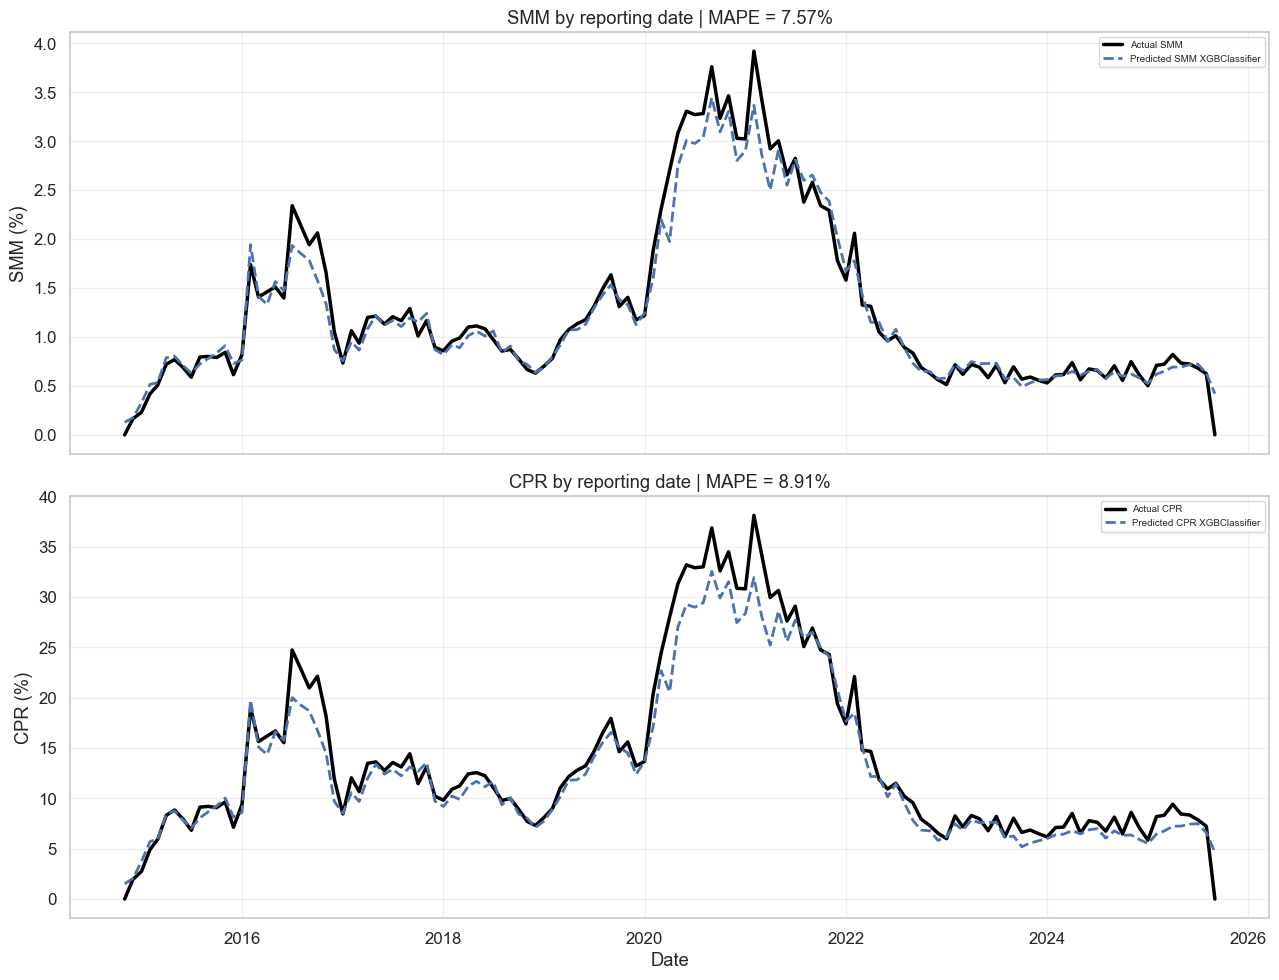

In [34]:
plot_smm_cpr(test_pd, X_test, model)

In [33]:
def plot_smm_cpr(test_pd, X_test, model):
    test_pd = test_pd.copy()

    # --- actual ---
    agg = (
        test_pd.groupby("reporting_date")
        .agg(
            n=(TARGET_COL, "count"),
            n_prepaid=(TARGET_COL, "sum")
        )
        .reset_index()
    )
    agg["smm"] = agg["n_prepaid"] / agg["n"]
    agg["cpr"] = (1 - (1 - agg["smm"]) ** 12) * 100
    agg = agg.sort_values("reporting_date")

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

    a1.plot(
        agg["reporting_date"],
        agg["smm"] * 100,
        color="black",
        lw=2.5,
        label="Actual SMM"
    )
    a2.plot(
        agg["reporting_date"],
        agg["cpr"],
        color="black",
        lw=2.5,
        label="Actual CPR"
    )

    # --- predicted ---
    prob = model_inference(model, X_test)
    smm = _correct(prob)
    cpr = 1 - (1 - smm) ** 12

    test_pd["smm_pred"] = smm * 100
    test_pd["cpr_pred"] = cpr * 100

    agg2 = (
        test_pd.groupby("reporting_date")
        .agg(
            smm_pred=("smm_pred", "mean"),
            cpr_pred=("cpr_pred", "mean")
        )
        .reset_index()
        .sort_values("reporting_date")
    )

    a1.plot(
        agg2["reporting_date"],
        agg2["smm_pred"],
        lw=2.0,
        linestyle="--",
        label="Predicted SMM " + type(model).__name__
    )
    a2.plot(
        agg2["reporting_date"],
        agg2["cpr_pred"],
        lw=2.0,
        linestyle="--",
        label="Predicted CPR " + type(model).__name__
    )

    # --- merge for MAPE ---
    merged = agg.merge(agg2, on="reporting_date", how="inner")

    # actual SMM is in percent on the chart
    merged["smm_actual_pct"] = merged["smm"] * 100

    # avoid division by zero in MAPE
    smm_mask = merged["smm_actual_pct"] != 0
    cpr_mask = merged["cpr"] != 0

    smm_mape = (
        np.abs(
            (merged.loc[smm_mask, "smm_actual_pct"] - merged.loc[smm_mask, "smm_pred"])
            / merged.loc[smm_mask, "smm_actual_pct"]
        ).mean() * 100
        if smm_mask.any() else np.nan
    )

    cpr_mape = (
        np.abs(
            (merged.loc[cpr_mask, "cpr"] - merged.loc[cpr_mask, "cpr_pred"])
            / merged.loc[cpr_mask, "cpr"]
        ).mean() * 100
        if cpr_mask.any() else np.nan
    )

    a1.set_title(f"SMM by reporting date | MAPE = {smm_mape:.2f}%")
    a2.set_title(f"CPR by reporting date | MAPE = {cpr_mape:.2f}%")

    a1.set_ylabel("SMM (%)")
    a1.legend(fontsize=7)
    a1.grid(alpha=0.3)

    a2.set_ylabel("CPR (%)")
    a2.set_xlabel("Date")
    a2.legend(fontsize=7)
    a2.grid(alpha=0.3)

    fig.tight_layout()

In [76]:
model_dir = os.path.join(out_path, "saved_models")

In [77]:
lr_model = load_model(os.path.join(model_dir, "lr.pkl"))
rf_model = load_model(os.path.join(model_dir, "rf.pkl"))
sgd_model = load_model(os.path.join(model_dir, "sgd.pkl"))
xgb_model = load_model(os.path.join(model_dir, "xgb.pkl"))
lgb_model = load_model(os.path.join(model_dir, "lgb.pkl"))

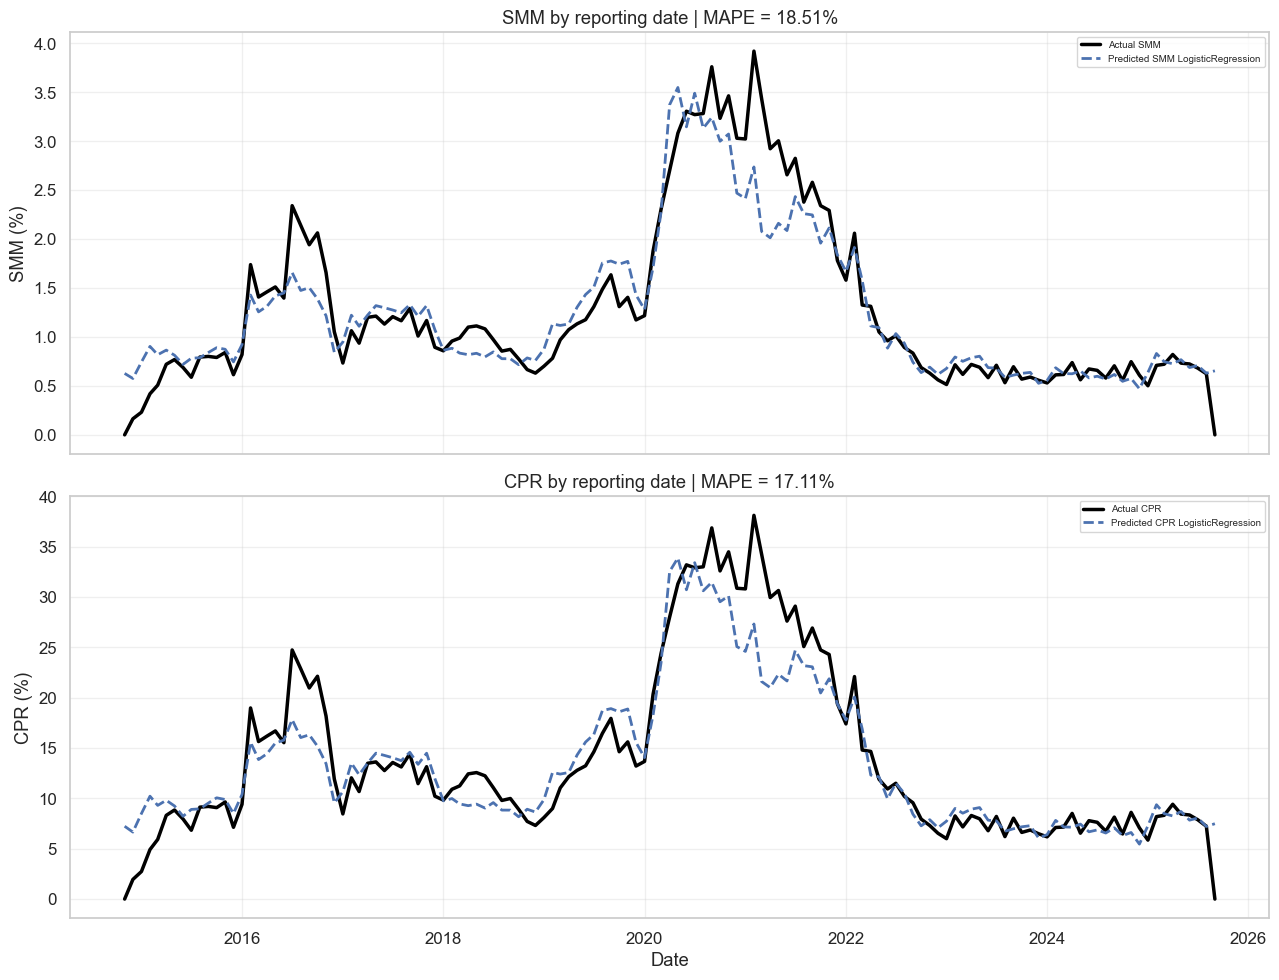

In [78]:
plot_smm_cpr(test_pd, X_test, lr_model)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    3.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   14.1s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:   22.3s finished


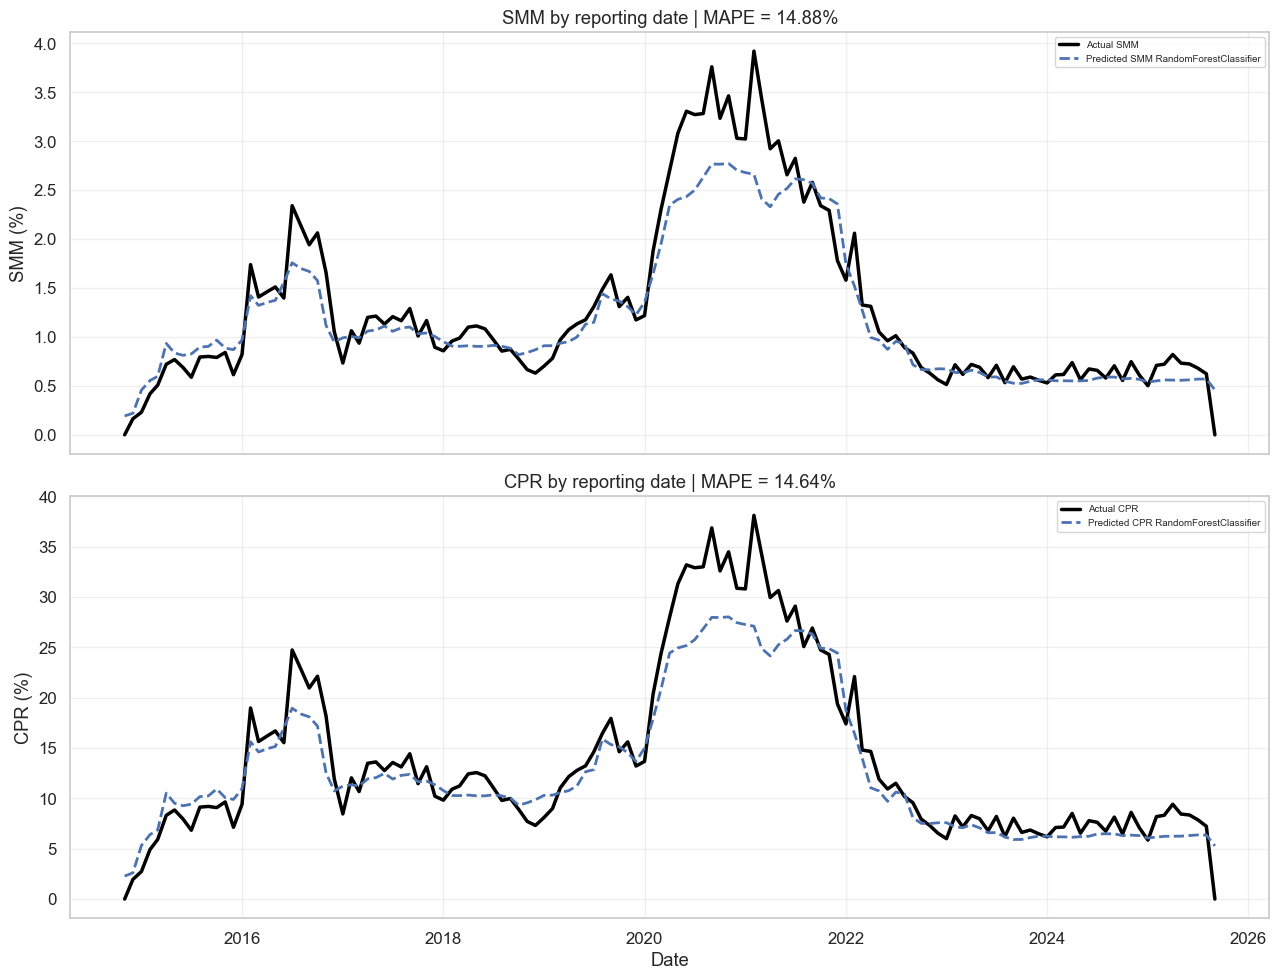

In [79]:
plot_smm_cpr(test_pd, X_test, rf_model)

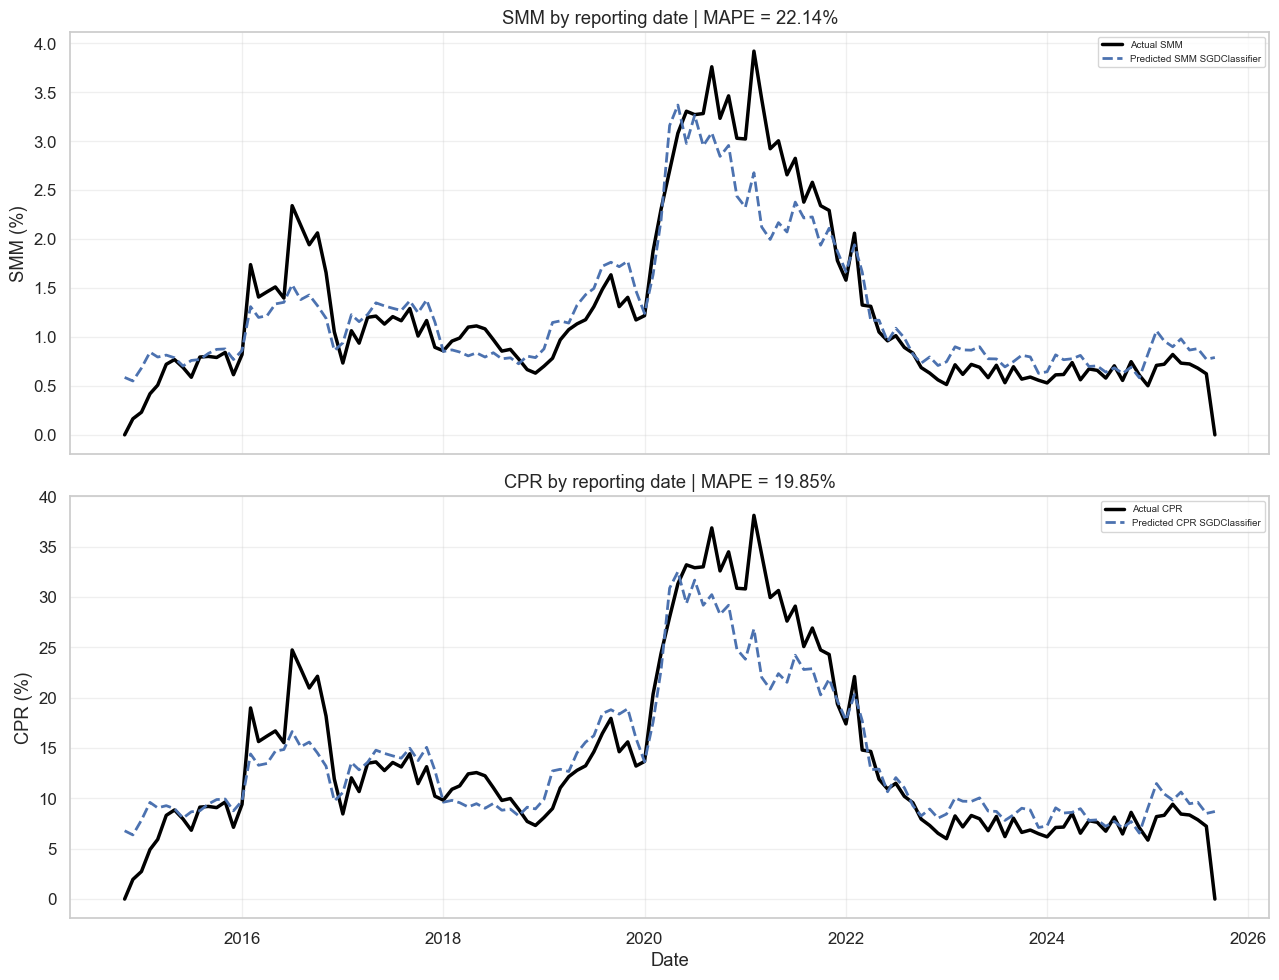

In [80]:
plot_smm_cpr(test_pd, X_test, sgd_model)

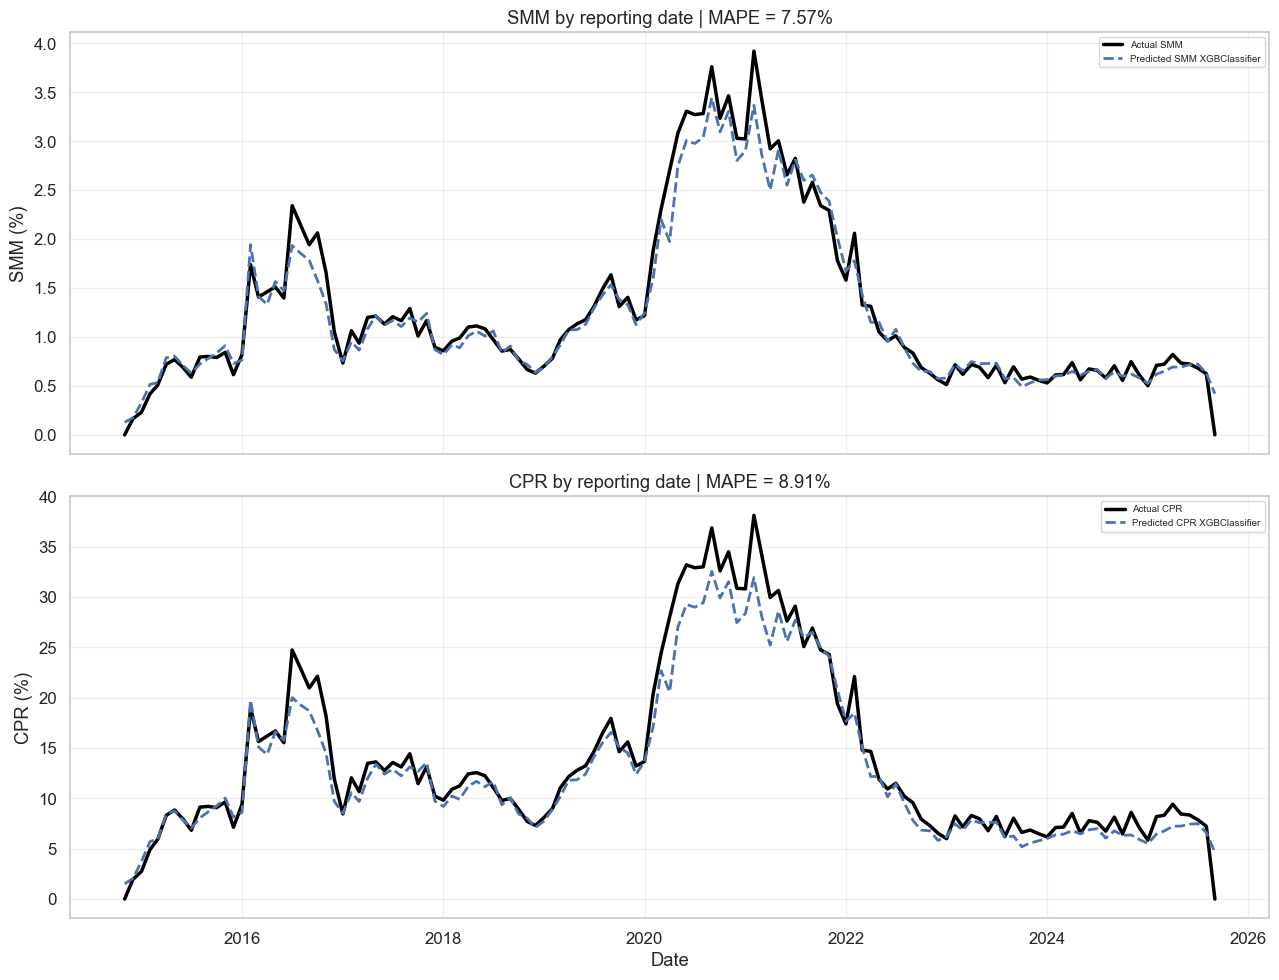

In [81]:
plot_smm_cpr(test_pd, X_test, xgb_model)

C:\Users\paine\.conda\envs\thesis\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


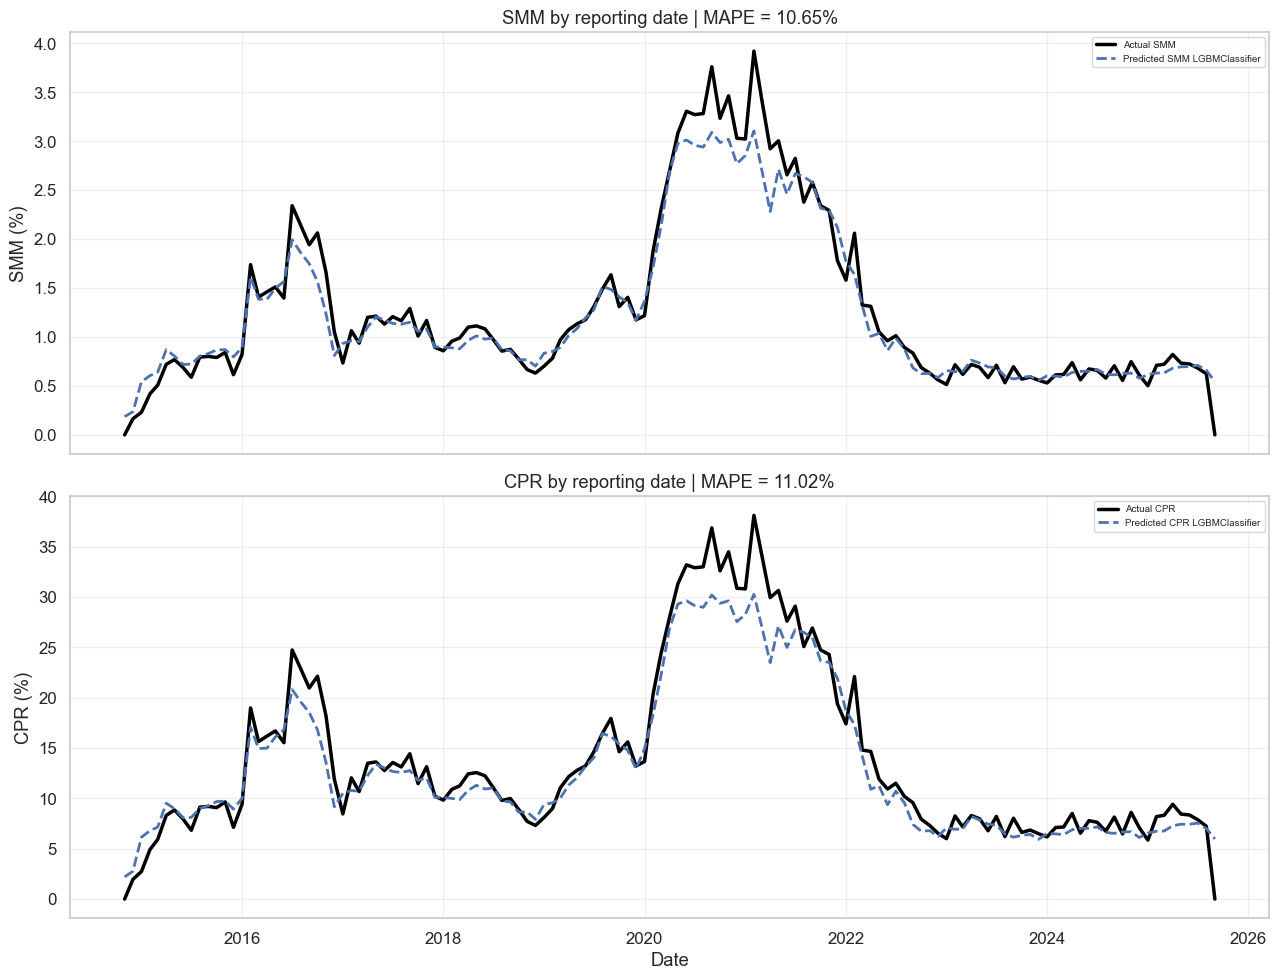

In [82]:
plot_smm_cpr(test_pd, X_test, lgb_model)

In [8]:
test_pd.head(1000).to_clipboard()